In [1]:
%cd ..
!ls

/home/suetin/Projects/UltrasoundCardiacReconstruction/MAE-Segmentation
config.yaml	models		  src		       train_unetr.py
eval_unetr.py	notebooks	  tests
images		README.md	  train_custom_MAE.py
lightning_logs	requirements.txt  train_transunet.py


/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch, cv2, os
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from natsort import natsorted

import torchvision.transforms as transforms

from src.mae import MAEPretrainer, get_mae_model
from src.datasets import EchoDataModule, EchoPretrainDataset

/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import yaml

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [4]:
def get_image_filepaths(main_path, format):
    
    # Сюда всё запишем
    filepaths = []
    # Итерируемся по всем пациентам
    for address, dirs, files in os.walk(main_path):
        # Все названия внутри каждого пациента
        for name in files:
            # Выбираем нужный формат
            if format in name:
                # Добавляем путь до изображения или маски
                if os.path.exists(os.path.join(address, name)):
                    filepaths.append(os.path.join(address, name))

    # assert len(files) == len(filepaths), f"There're another format of files, .txt, for instance. File is: {filepaths}"
    
    return natsorted(filepaths)

# Restore images to suitable images of opencv style
def ImgForPlot(img):
    # img = np.einsum('ijk->jki', img)
    # img = (127.5*(img+1)).astype(np.uint8)
    try:
        img = img.cpu().detach().numpy()
        return np.transpose(img, (1, 2, 0))
    except:
        print("Already numpy.array")
        return np.transpose(img, (1, 2, 0))

In [5]:
class LeftCamusDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        image_paths: list[str],
        LA_mask_paths: list[str],
        transforms=None,
        label_smooth: float | None = None
    ):
        """
        Args:
          image_paths: list of RGB echo image filepaths.
          LA_mask_paths: list of binary mask paths for LA (will infer LV).
          transforms: torchvision or albumentations to apply to both image & label.
          label_smooth: optional small value to smooth binary masks.
        """
        assert len(image_paths) == len(LA_mask_paths)
        self.image_paths = image_paths
        self.la_paths = LA_mask_paths
        self.transforms = transforms
        self.label_smooth = label_smooth

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1) Load & normalize RGB image
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0  # now (H, W, 3)
        # img = img.transpose(2, 0, 1)  # (3, H, W)

        # 2) Load LA and LV masks, build 2-channel label
        la = cv2.imread(self.la_paths[idx], cv2.IMREAD_GRAYSCALE)
        lv_path = self.la_paths[idx].replace("echoLA", "echoLV")
        lv = cv2.imread(lv_path, cv2.IMREAD_GRAYSCALE)
        # threshold + optional smoothing
        la = (la > 0).astype(np.uint8)
        lv = (lv > 0).astype(np.uint8)
        if self.label_smooth:
            la = np.where(la, 1 - self.label_smooth, 0).astype(np.float32)
            lv = np.where(lv, 1 - self.label_smooth, 0).astype(np.float32)
        # combine: 0=BG,1=LV,2=LA
        label = np.zeros_like(la, dtype=np.uint8)
        label[lv == 1] = 255
        label[la == 1] = 128  # if overlap, LA takes precedence


        # 3) Apply joint transforms (if provided)
        if self.transforms:
            img = self.transforms(img)
            label = self.transforms(label)

        # # 4) To torch tensors
        # img_t = torch.from_numpy(img).permute(2, 0, 1)  # (3,H,W)
        # lbl_t = torch.from_numpy(label).long()          # (H,W)

        return {"pixel_values": img, "labels": label}


In [6]:
train_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/training"
test_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/testing"

img_train_paths = get_image_filepaths(os.path.join(train_path, "images"), format='.jpg')
img_test_paths = get_image_filepaths(os.path.join(test_path, "images"), format='.jpg')

msk_train_paths = get_image_filepaths(os.path.join(train_path, "masks"), format='.png')
msk_test_paths = get_image_filepaths(os.path.join(test_path, "masks"), format='.png')

len(img_train_paths), len(msk_test_paths)

(20997, 2235)

In [7]:
data_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224,224)),
    # transforms.Normalize(0.5, 0.5)
])

# data_transform = None

train_dataset = LeftCamusDataset(img_train_paths, msk_train_paths, transforms=data_transform)
test_dataset = LeftCamusDataset(img_test_paths, msk_test_paths, transforms=data_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)

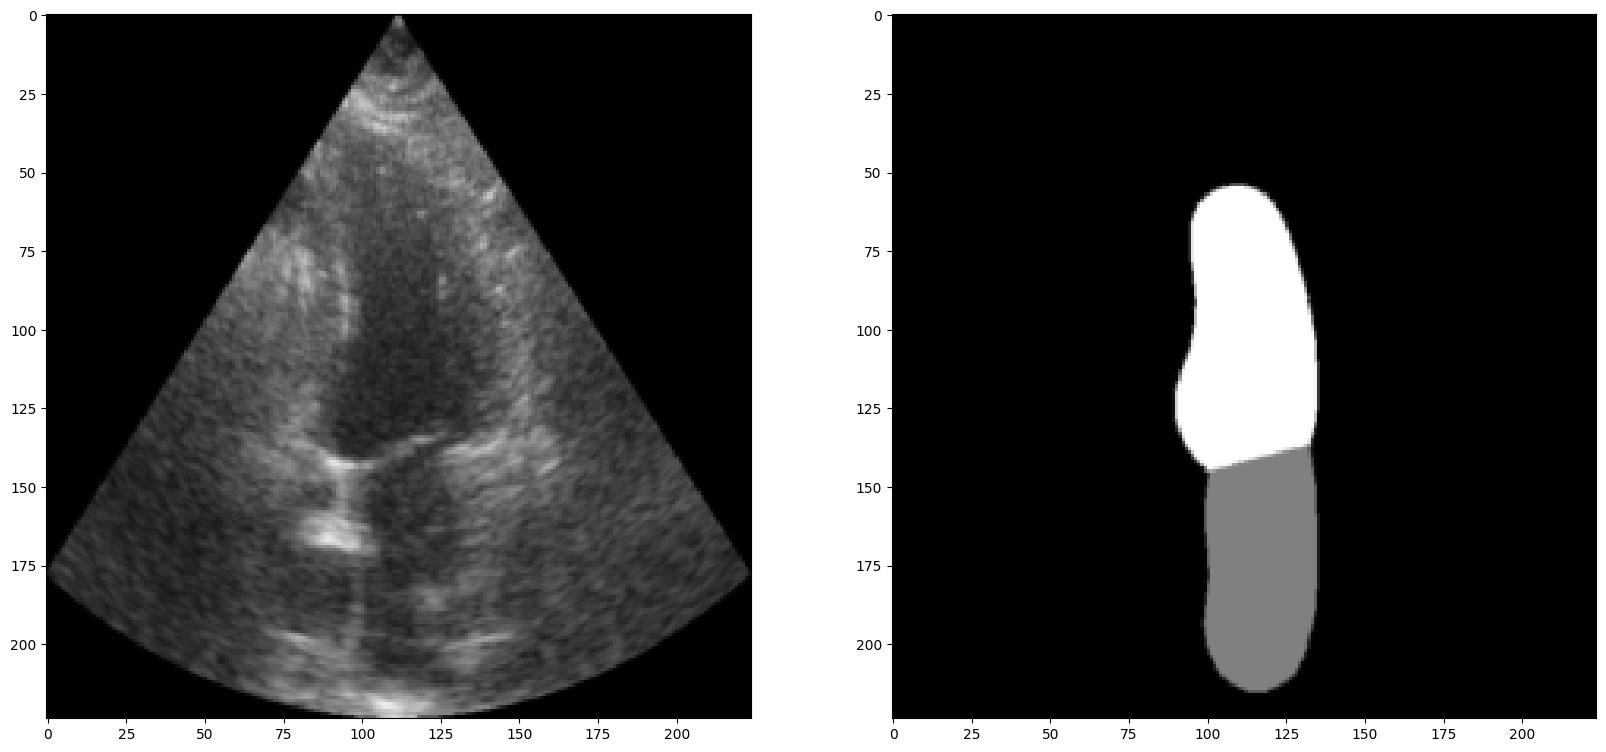

In [8]:
batch = next(iter(test_loader))
fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(batch['pixel_values'][0]), 'gray');
plt.subplot(122)
# plt.imshow(ImgForPlot(batch['labels']).sum(axis=-1), 'gray');
plt.imshow(batch['labels'][0].squeeze(0), 'gray');

In [9]:
labels = batch['labels'][0].squeeze(0).cpu().detach().numpy()
torch.unique(batch['labels'], return_counts=True), batch['labels'].shape

((tensor([0.0000e+00, 9.4172e-05, 9.4212e-05,  ..., 1.0000e+00, 1.0000e+00,
          1.0000e+00]),
  tensor([341815,      2,      1,  ...,   3237,  14530,  14454])),
 torch.Size([8, 1, 224, 224]))

In [10]:
batch['pixel_values'][0].shape,  batch['labels'][0].shape

(torch.Size([3, 224, 224]), torch.Size([1, 224, 224]))

## Model

https://arxiv.org/pdf/2102.04306
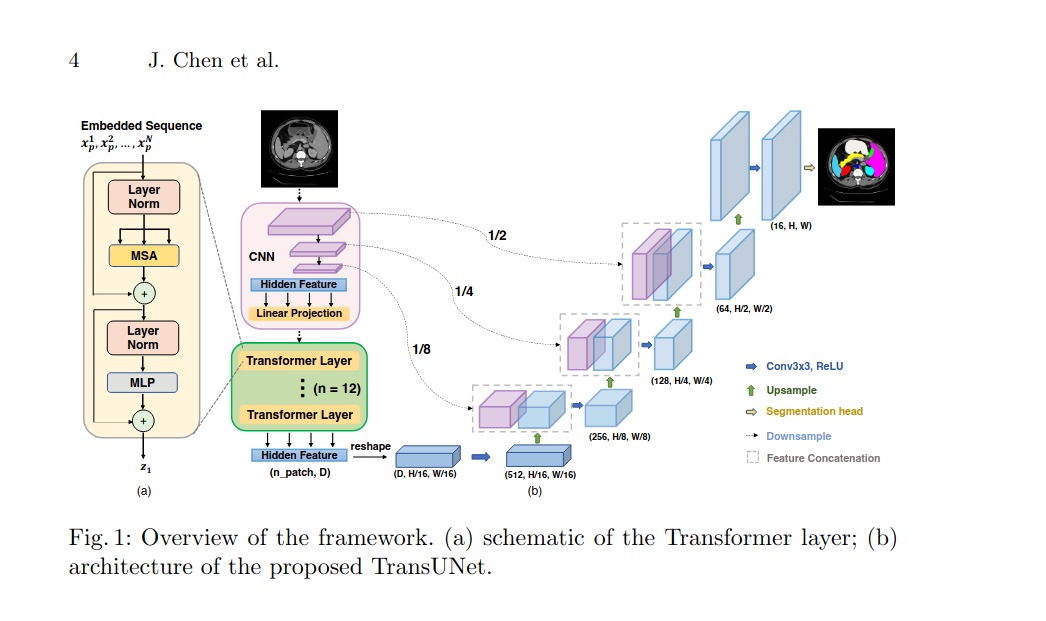

In [11]:
from src.TransUNet import TransUNet

In [12]:
# Paths to your MAE config and checkpoint
mae_cfg_path = "models/mae_pretrained/config.json"
mae_ckpt_path = "models/mae_pretrained.pth"  # or .pth

# 1) Instantiate TransUNet with MAE weights
model = TransUNet(
    mae_config_path=mae_cfg_path,
    mae_checkpoint_path=mae_ckpt_path,
    num_classes=3,
    freeze_encoder_blocks=0
)

# 2) Example forward
x = torch.randn(2, 3, 224, 224)
seg_logits = model(x)  # shape (2, 4, 224, 224)
seg_logits.shape, seg_logits.dtype

Missing keys: ['pooler.dense.weight', 'pooler.dense.bias']
Unexpected keys: []


/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


(torch.Size([2, 3, 224, 224]), torch.float32)

In [13]:
from torchinfo import summary 
summary(model, input_size=(1, 3, 224, 224), depth=3, col_names=["input_size", "output_size", "num_params", "trainable"], row_settings=["var_names"])

Layer (type (var_name))                                                Input Shape               Output Shape              Param #                   Trainable
TransUNet (TransUNet)                                                  [1, 3, 224, 224]          [1, 3, 224, 224]          2,049,000                 Partial
├─ModuleList (backbone_layers)                                         --                        --                        14,964,736                True
│    └─Sequential (0)                                                  [1, 3, 224, 224]          [1, 64, 112, 112]         --                        True
│    │    └─Conv2d (0)                                                 [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
│    │    └─BatchNorm2d (1)                                            [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
│    │    └─ReLU (2)                                                

torch.Size([8, 3, 224, 224])

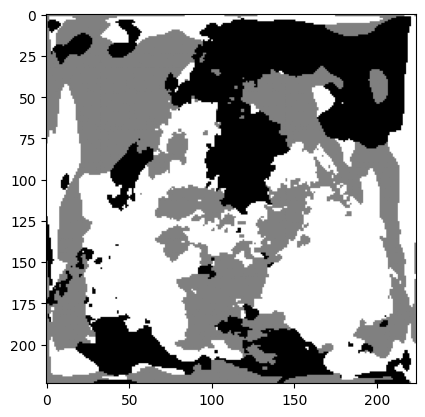

In [14]:
out = model(batch['pixel_values'].to('cuda'))
plt.imshow(out[0].argmax(dim=0).cpu().detach().numpy(), 'gray');
out.shape

In [15]:
import torch.nn as nn
from PIL import Image
import pytorch_lightning as pl # MulticlassDice

# ------------------------- Fixing the Label Pipeline -------------------------
# When using torchvision.transforms.Resize, it interpolates masks as float
# and can produce non-binary values like 0.5. Best practice for masks:
# - Resize using interpolation=InterpolationMode.NEAREST
# - Convert mask to long type with class indices (0, 1)

from torchvision.transforms import InterpolationMode


def mask_to_index(mask_tensor):
    # Input: Tensor (1, H, W) with values in [0, 127, 255]
    # Output: Tensor (H, W) with class indices [0=bg, 1=LA, 2=LV]
    mask = mask_tensor.squeeze(0)
    out = torch.zeros_like(mask, dtype=torch.long)
    out[mask == 127] = 1  # LA
    out[mask == 255] = 2  # LV
    return out

def build_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), interpolation=InterpolationMode.BILINEAR),
        transforms.Normalize(0.5, 0.5)
    ])

def build_mask_transform():
    """
    Returns a transform that takes a PIL.Image mask (values {0,127,255})
    and outputs a LongTensor of shape (H, W) with values {0,1,2}.
    """
    return transforms.Compose([
        transforms.ToTensor(),
        # 1) Resize with NEAREST so we keep exact labels
        transforms.Resize((224, 224), interpolation=InterpolationMode.NEAREST),
        # 2)
        transforms.Lambda(lambda x: (x*2).long()),  # map 255 -> 1 (LV), 127 -> 0 (LA)
    ])

In [16]:
from src.datasets import LeftCamusDataset
from src.unetr_model import UNETRModule 


train_dataset = LeftCamusDataset(img_train_paths, 
                                 msk_train_paths, 
                                 img_transforms=build_transforms(), 
                                 msk_transforms=build_mask_transform())
test_dataset = LeftCamusDataset(img_test_paths, 
                                msk_test_paths, 
                                img_transforms=build_transforms(), 
                                msk_transforms=build_mask_transform()
                                )

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cfg['batch_size'] // 2, shuffle=False)

(tensor([0, 1, 2]), tensor([334057,  24621,  42730]))


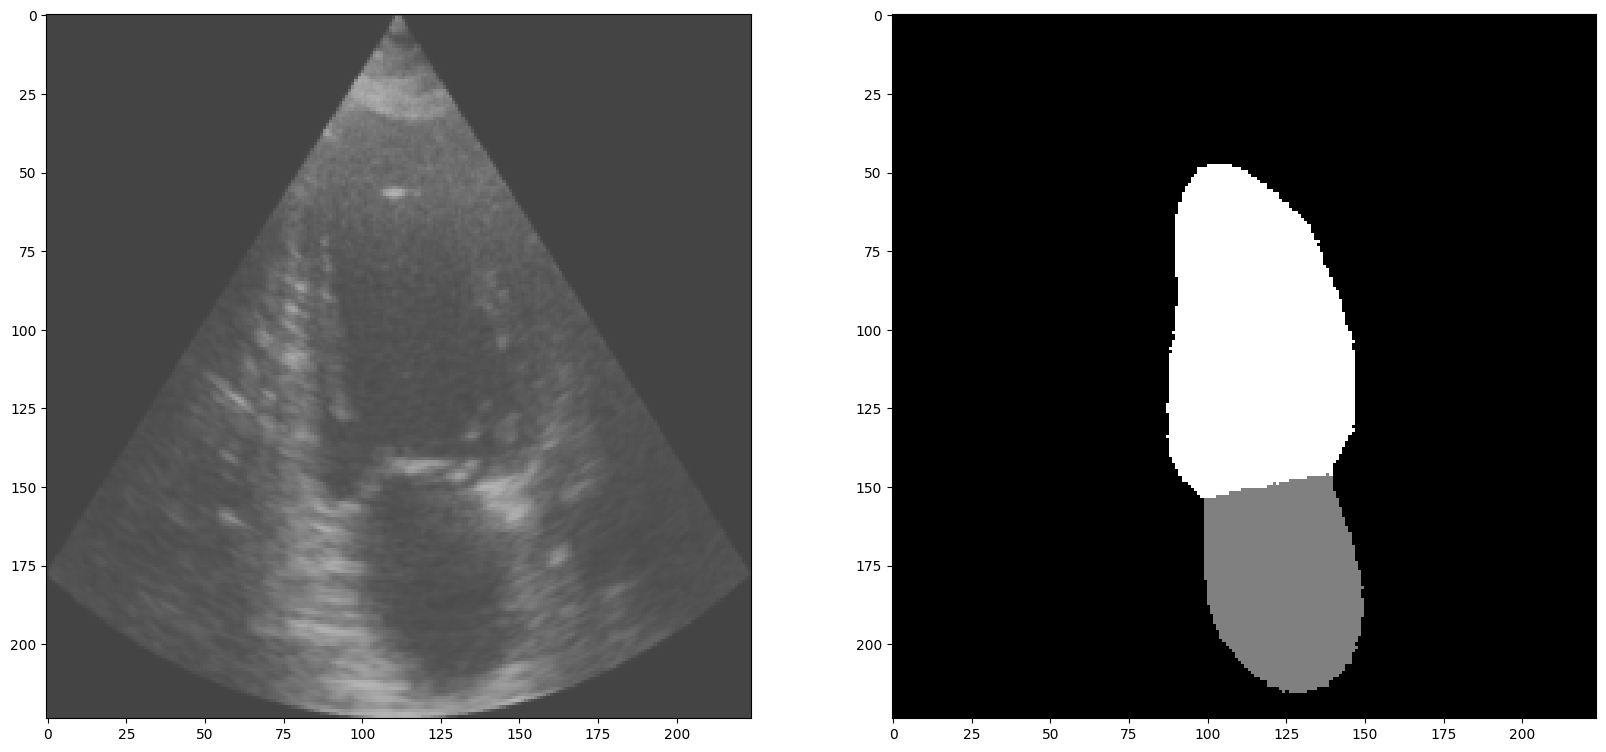

In [17]:
batch = next(iter(test_loader))
print(torch.unique(batch['labels'], return_counts=True))

fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(batch['pixel_values'][0].sigmoid()), 'gray');
plt.subplot(122)
# plt.imshow(ImgForPlot(batch['labels']).sum(axis=-1), 'gray');
plt.imshow(batch['labels'][0].squeeze(0), 'gray');

In [18]:
# unetr_model = UNETRModule(model=model, lr=cfg['lr'], loss_type=cfg['loss_type'])

# trainer = pl.Trainer(
#     max_epochs=cfg['epochs'],
#     precision=16,        # mixed precision for speed
#     accelerator="auto",
#     gradient_clip_val=1.0,
#     accumulate_grad_batches=5,
# )
# trainer.fit(unetr_model, train_loader, test_loader)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

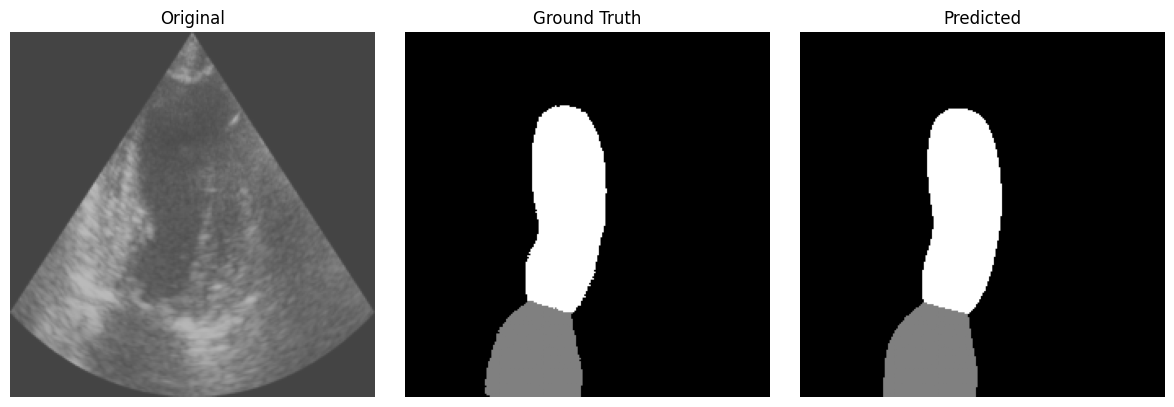

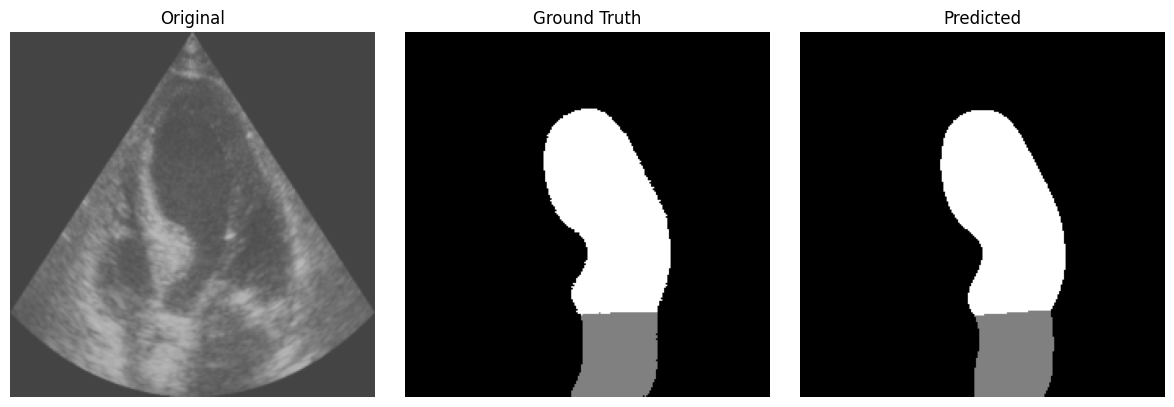

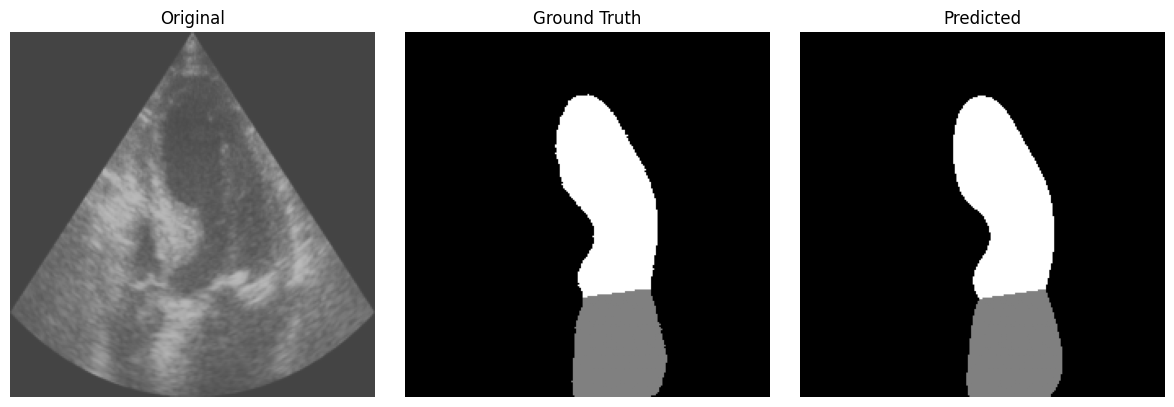

In [20]:
state_dict = torch.load("models/transunet_model.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

# 3. Get 3 samples from the test loader
# Assume test_loader yields dicts: {"pixel_values": Tensor[B,3,224,224], "labels": Tensor[B,224,224]}
batch = next(iter(test_loader))
images = batch["pixel_values"][-3:].to(device)  # (3,3,224,224)
masks  = batch["labels"][-3:].to(device)        # (3,224,224)

# 4. Run inference
with torch.no_grad():
    logits = model(images)                     # (3,2,224,224)
    preds  = torch.argmax(logits, dim=1)       # (3,224,224)

# 5. Plot side-by-side
def plot_triplet(img, gt_mask, pred_mask, idx):
    img_np = img.sigmoid().cpu().permute(1,2,0).numpy()
    gt_np  = gt_mask.cpu().permute(1,2,0).numpy()
    pr_np  = pred_mask.cpu().numpy()
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2)
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2)
    axes[2].set_title("Predicted")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_triplet(images[i], masks[i], preds[i], i)

In [21]:
from torchmetrics.classification import Dice
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import JaccardIndex
from tqdm import tqdm

dice_metric = Dice(num_classes=3, average='macro').to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9151381].


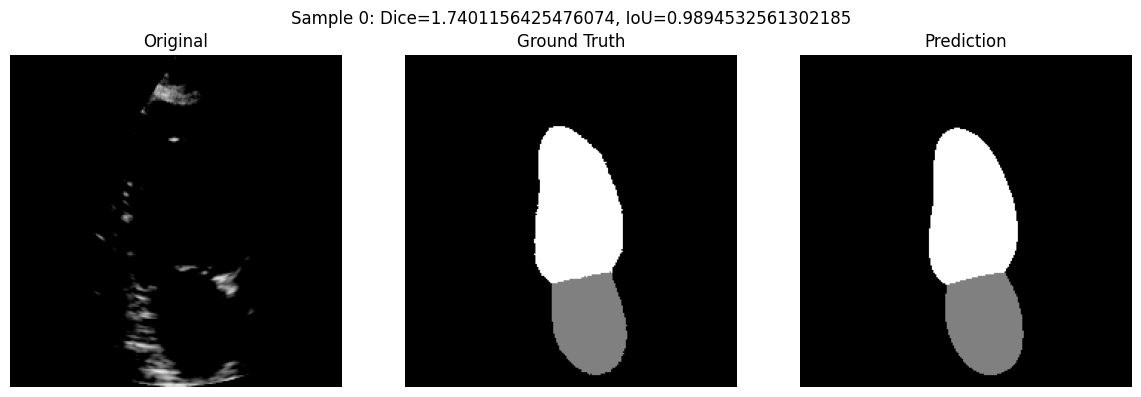

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.95792174].


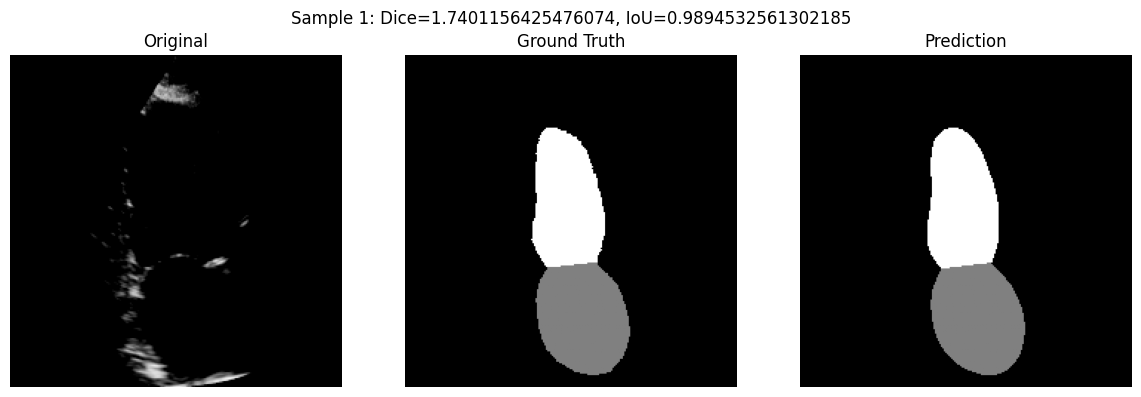

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.927775].


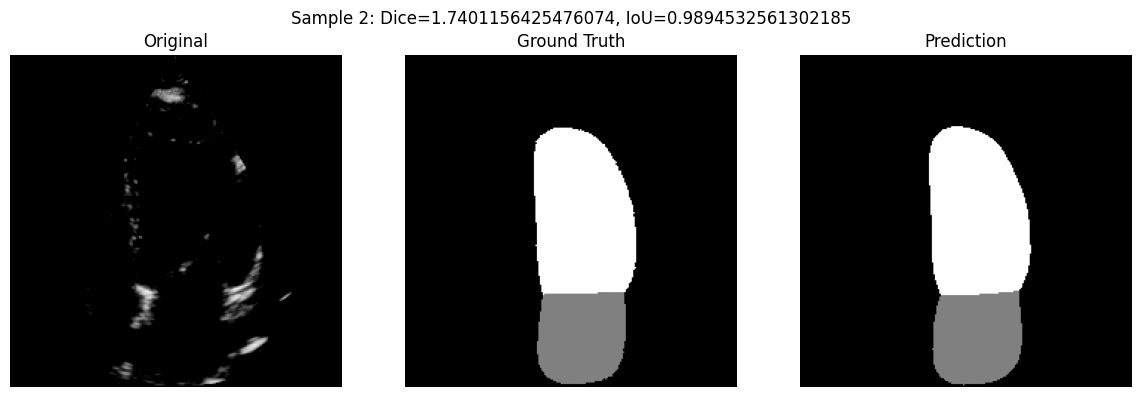

In [22]:
# 2) Prepare one batch
batch = next(iter(test_loader))
imgs = batch["pixel_values"].to(device)      # (3, 3, 224, 224)
gts  = batch["labels"].squeeze(1).to(device) # (3, 224, 224)

# 3) Inference
with torch.no_grad():
    logits = model(imgs)                     # (3, 3, 224, 224)
    preds  = torch.argmax(logits, dim=1)     # (3, 224, 224)

# 4) Compute metrics in one shot
dice = DiceScore(num_classes=3, average="micro").to(device)   # micro‑averaged Dice :contentReference[oaicite:0]{index=0}
iou  = JaccardIndex(num_classes=3, task="multiclass", average="micro").to(device) # micro‑averaged IoU :contentReference[oaicite:1]{index=1}
# (preds, gts), (preds, gts)

# print(f"Batch Dice: {dice.item():.4f}, Batch IoU: {iou.item():.4f}")

# 5) Plot Originals, GT, Predictions
def plot_row(img, gt, pred, idx):
    img_np  = img.cpu().permute(1,2,0).numpy()
    gt_np   = gt.cpu().numpy()
    pr_np   = pred.cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_np);     ax[0].set_title("Original")
    ax[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2); ax[1].set_title("Ground Truth")
    ax[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2); ax[2].set_title("Prediction")

    iou.update(preds, gts)
    dice.update(preds, gts)
    jaccard_val = iou.compute().item()
    dice_val    = dice.compute().item()

    for a in ax: a.axis("off")
    plt.suptitle(f"Sample {idx}: Dice={dice_val}, IoU={jaccard_val}")
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_row(imgs[i], gts[i], preds[i], i)

Testing:   0%|          | 0/280 [00:00<?, ?it/s]

Testing: 100%|██████████| 280/280 [00:30<00:00,  9.03it/s]


Test Jaccard (IoU): 0.9762
Test Dice:         1.7027


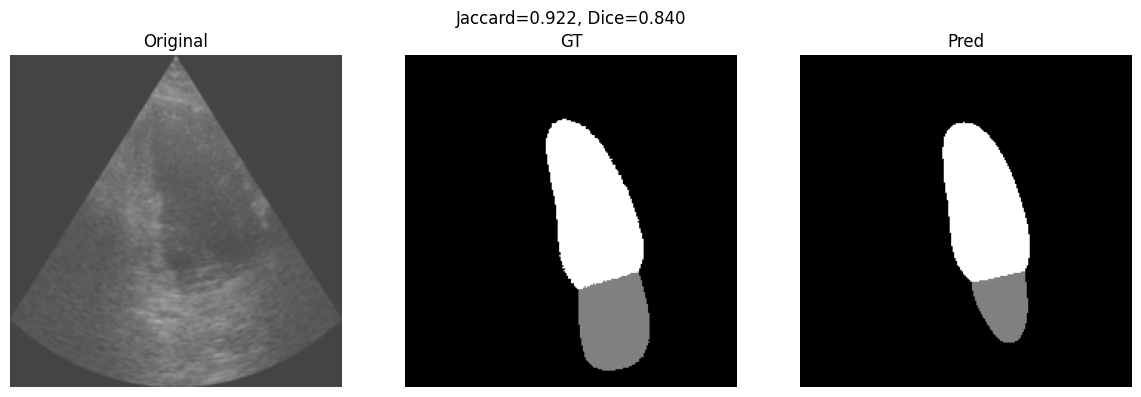

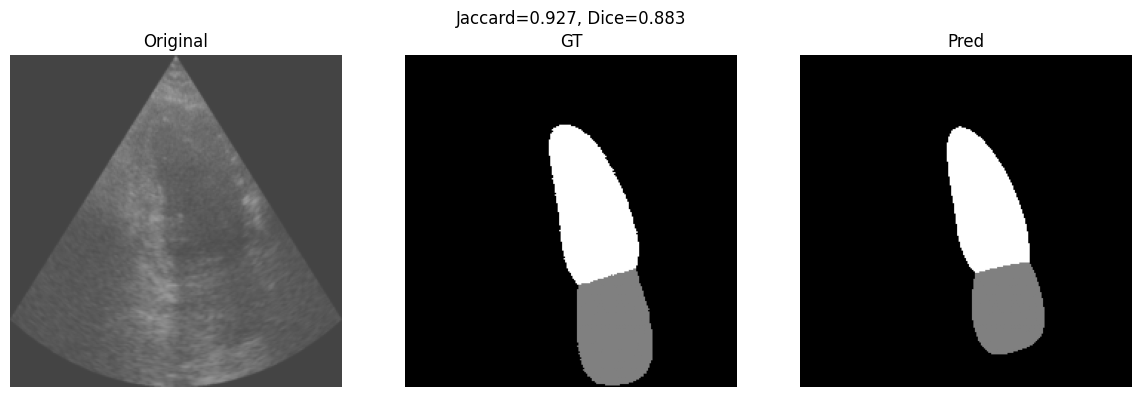

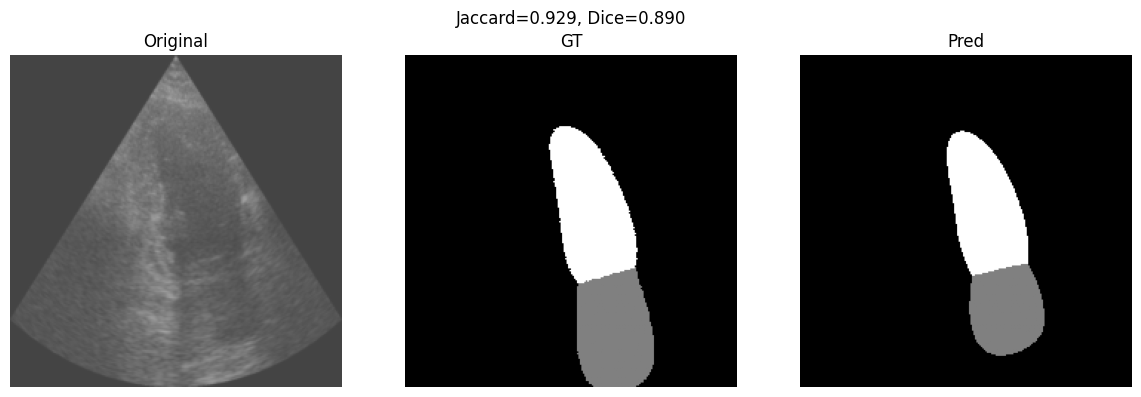

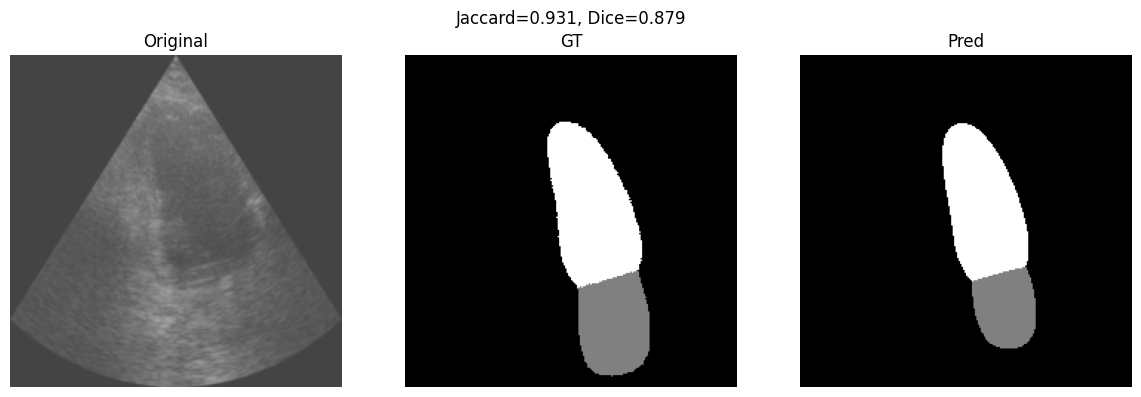

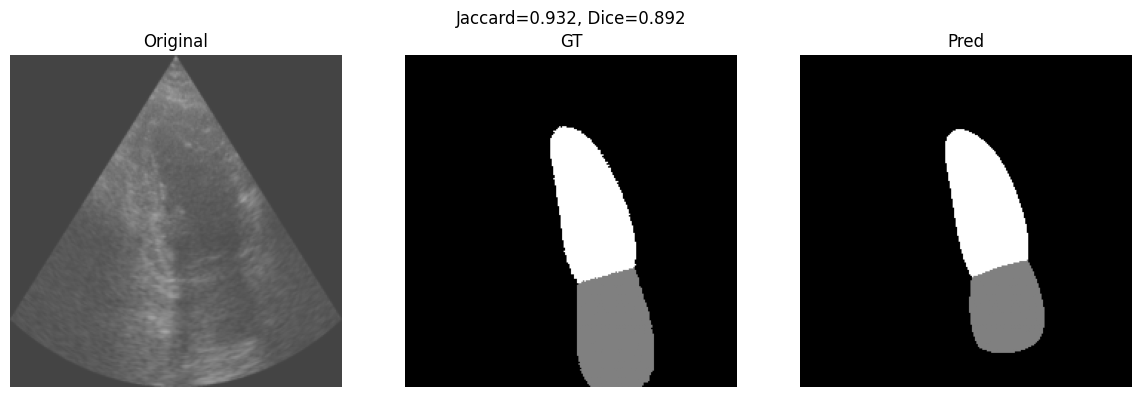

In [26]:
# 4) Compute metrics in one shot
dice = DiceScore(num_classes=3, average="micro").to(device)   # micro‑averaged Dice :contentReference[oaicite:0]{index=0}
iou  = JaccardIndex(num_classes=3, task="multiclass", average="micro").to(device) # micro‑averaged IoU :contentReference[oaicite:1]{index=1}

# 3) Storage for per-sample scores and data (for worst‑n later)
records = []  # list of (jacc, dice, img, gt, pred)

# 4) Full evaluation loop
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        imgs = batch["pixel_values"].to(device)      # (B,3,H,W)
        gts  = batch["labels"].squeeze(1).to(device) # (B,H,W)

        logits = model(imgs)                         # (B,3,H,W)
        preds  = torch.argmax(logits, dim=1)         # (B,H,W)

        # 4a) Update global metrics
        iou.update(preds, gts)
        dice.update(preds, gts)

        # 4b) Compute per-sample
        for i in range(imgs.size(0)):
            jc = iou(
                preds[i].unsqueeze(0),
                gts[i].unsqueeze(0)
            ).item()
            dc = dice_metric(   # dice
                preds[i].unsqueeze(0),
                gts[i].unsqueeze(0)
            )# .item()
            records.append((
                jc, dc,
                imgs[i].cpu(),    # keep image for later
                gts[i].cpu(),
                preds[i].cpu()
            ))

# 5) Compute and print aggregate metrics
mean_jaccard = iou.compute().item()
mean_dice    = dice.compute().item()
print(f"Test Jaccard (IoU): {mean_jaccard:.4f}")
print(f"Test Dice:         {mean_dice:.4f}")

# 6) Visualize the worst-N by Jaccard
worst_n = 5
records.sort(key=lambda x: x[0])  # sort ascending by Jaccard

def plot_row(img, gt, pred, title=""):
    img_np  = img.sigmoid().permute(1,2,0).numpy()
    gt_np   = gt.numpy()
    pr_np   = pred.numpy()
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(img_np);     ax[0].set_title("Original")
    ax[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2); ax[1].set_title("GT")
    ax[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2); ax[2].set_title("Pred")
    plt.suptitle(title)
    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.show()

for idx in range(worst_n):
    jc, dc, img, gt, pred = records[idx]
    plot_row(img, gt, pred, title=f"Jaccard={jc:.3f}, Dice={dc:.3f}")